# 02 · Refh classification and 3DEP pseudo-reference

**Research question.** What class labels does the deterministic refh classifier assign from CASALS H5 inputs alone, and how do those predictions compare with spatially transferred 3DEP labels under explicit point-index alignment?

Classification is run first without a reference. A separate call loads the transferred reference and evaluates the existing predictions. The transferred labels are pseudo-reference labels: some CASALS points have no nearby 3DEP support and are assigned class 7 by the transfer policy. They are not independent ground truth or an absolute-accuracy certification.

## Paths and parameters

The H5 and reference LAZ are explicit. A missing 3DEP transfer is an error with the command to generate it. This notebook does not discover a result by modification time or search archived outputs.

In [1]:
from pathlib import Path
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

ROOT = Path.cwd()
if not (ROOT / "casals_l1b").is_dir():
    raise RuntimeError("Run this notebook from the CASALS repository root.")
H5_PATH = ROOT / "data/raw/casals_l1b/casals_l1b_20241112T165718_001_02.h5"
REFERENCE_PATH = ROOT / "outputs/notebooks/02_refh_classification/reference_transfer/casals_l1b_20241112T165718_001_02.laz"
SUMMARY_PATH = REFERENCE_PATH.with_name(REFERENCE_PATH.stem + "_summary.json")
OUTPUT_ROOT = ROOT / "outputs/notebooks/02_refh_classification/scientific_review/classification_no_reference"
PLOT_SAMPLE = 45_000
SEED = 42
if not H5_PATH.exists():
    raise FileNotFoundError(f"Missing CASALS input: {H5_PATH}")
print(f"Prediction input: {H5_PATH.relative_to(ROOT)}")
print(f"Prediction artifacts: {OUTPUT_ROOT.relative_to(ROOT)}")
print("Transferred pseudo-reference will be checked only after H5-only prediction.")

Prediction input: data\raw\casals_l1b\casals_l1b_20241112T165718_001_02.h5
Prediction artifacts: outputs\notebooks\02_refh_classification\scientific_review\classification_no_reference
Transferred pseudo-reference will be checked only after H5-only prediction.


## H5-only prediction

The API receives the CASALS H5 and classifier configuration only. No reference labels are passed to the prediction call. The generated LAZ and run metadata record `evaluation.status = not_run`.

In [2]:
from casals_l1b.classification import DEFAULT_CONFIG, LABEL_ORDER, CLASS_NAME_MAP
from casals_l1b.classification_cli import classify_refh, build_output_paths

config = dict(DEFAULT_CONFIG)
config["OUTPUT_ROOT"] = OUTPUT_ROOT
config["WRITE_DIAGNOSTIC_PNG"] = False
config["WRITE_ERROR_FEATURE_SUMMARY"] = False
classification_result = classify_refh(H5_PATH, config)
if classification_result["status"] != "success":
    raise RuntimeError(classification_result.get("error", "classification failed"))
classification_arrays = classification_result["classification_summary_arrays"]
prediction_class = np.asarray(classification_arrays["pred_class_baseline"], dtype=np.uint8)
class_codes, class_values = np.unique(prediction_class, return_counts=True)
class_counts = {int(k): int(v) for k, v in zip(class_codes, class_values)}
classification_output = build_output_paths(OUTPUT_ROOT, H5_PATH.stem)
metadata = json.loads(Path(classification_result["metadata_path"]).read_text(encoding="utf-8"))
assert metadata["evaluation"]["status"] == "not_run"
print("Prediction status:", classification_result["status"])
print("Evaluation metadata:", metadata["evaluation"])
print("Prediction classes:", class_counts)
print("Classified LAZ:", classification_output["classified_laz"])

Processing: casals_l1b_20241112T165718_001_02


Read CASALS points: 3,604,480


Ground support candidates: 42,740
Valid ground grid cells: 1,213


Classifier mode: rule_combined_v1
Density source: computed_internal
Rule switches: near_ground=False, signal_density=False, dtm_support=False, scanline=True, below_ground=False
Predicted class counts: {1: 290733, 2: 1346761, 7: 1966986}
Predicted class counts table
 code                   name   count
    1 processed_unclassified  290733
    2                 ground 1346761
    7                  noise 1966986
Classification reason counts
 code                             name   count
    1        ground_abs_hag_within_tol 1346761
    2         unclassified_missing_dtm     196
    3               noise_below_ground  814583
    4              noise_above_max_hag 1117545
    5 processed_unclassified_valid_hag  290537
    9 noise_low_density_processed_only   34858
Density valid fraction: 1.000000
Density quantiles by predicted class
 class_code             class_name  density_p05  density_median  density_p95
          1 processed_unclassified     0.024828        0.133690     0.903363
    

Wrote: C:\Users\zhong267\OneDrive - purdue.edu\CASALS\outputs\notebooks\02_refh_classification\scientific_review\classification_no_reference\casals_l1b_20241112T165718_001_02\casals_l1b_20241112T165718_001_02_baseline_classified.laz
Prediction status: success
Evaluation metadata: {'status': 'not_run', 'reason': 'no_reference_provided'}
Prediction classes: {1: 290733, 2: 1346761, 7: 1966986}
Classified LAZ: C:\Users\zhong267\OneDrive - purdue.edu\CASALS\outputs\notebooks\02_refh_classification\scientific_review\classification_no_reference\casals_l1b_20241112T165718_001_02\casals_l1b_20241112T165718_001_02_baseline_classified.laz


## Point-index alignment and transferred-label coverage

The 3DEP transfer file carries the zero-based CASALS `point_index`, so the alignment is explicit. Alignment says which prediction row a pseudo-label refers to; it does not say that a nearby 3DEP return was available. Transfer status and confidence fields are therefore reported separately.

In [3]:
from casals_l1b.evaluation import (
    read_reference_labels, align_prediction_to_reference,
    map_reference_labels_to_baseline_classes, evaluate_classification,
)
from casals_l1b.refh import read_refh_points, project_refh_points
import laspy

if not REFERENCE_PATH.exists() or not SUMMARY_PATH.exists():
    raise FileNotFoundError(
        f"Missing transferred pseudo-reference or provenance summary: {REFERENCE_PATH} / {SUMMARY_PATH}. "
        "Generate it with:\n"
        "python -m casals_l1b reference transfer --casals-h5 "
        "data/raw/casals_l1b/casals_l1b_20241112T165718_001_02.h5 "
        "--dep3-las data/reference/3dep/casals_l1b_20241112T165718_001_02_MD_Southeast_1_2019_EPSG6347_39a068a77804.laz "
        "--output-dir outputs/notebooks/02_refh_classification/reference_transfer"
    )
transfer_metadata = json.loads(SUMMARY_PATH.read_text(encoding="utf-8"))
metadata_h5 = Path(transfer_metadata["inputs"]["casals_h5"]).resolve()
assert metadata_h5 == H5_PATH.resolve(), (metadata_h5, H5_PATH.resolve())
dep3_path = Path(transfer_metadata["inputs"]["dep3_las"])
if not dep3_path.is_file():
    raise FileNotFoundError(f"Missing source 3DEP LAS/LAZ recorded in transfer metadata: {dep3_path}")
with laspy.open(dep3_path) as dep3_header:
    dep3_crs = dep3_header.header.parse_crs()
    assert dep3_crs is not None and dep3_crs.to_epsg() == 6347
    assert dep3_header.header.point_count == int(transfer_metadata["counts"]["dep3_points"])
assert transfer_metadata["inputs"]["dep3_header_crs"] == "EPSG:6347"
assert transfer_metadata["inputs"]["target_horizontal_crs"] == "EPSG:6347"
assert Path(transfer_metadata["outputs"]["labeled_las_or_laz"]).resolve() == REFERENCE_PATH.resolve()
assert "not rigorous geoid/datum transformation" in transfer_metadata["script_scope"]["vertical_alignment_semantics"]
assert "not be interpreted as rigorous vertical datum transformation" in transfer_metadata["coordinate_output"]["z_warning"]
assert transfer_metadata["coordinate_output"]["target_horizontal_crs" if "target_horizontal_crs" in transfer_metadata["coordinate_output"] else "x_y_crs"] == "EPSG:6347"

reference = read_reference_labels(REFERENCE_PATH)
reference["source_h5"] = str(metadata_h5)
required_dims = {"point_index", "longitude", "latitude", "transfer_status", "nearest3dep_dist_m",
                 "class_vote_ratio", "z_original_m"}
assert required_dims.issubset(set(reference["available_extra_dims"])), required_dims - set(reference["available_extra_dims"])
assert reference["point_count"] == int(transfer_metadata["counts"]["casals_points"])
assert reference["point_count"] == prediction_class.size
assert reference["crs"] is not None and reference["crs"].to_epsg() == 6347
reference_index = np.asarray(reference["point_index"], dtype=np.int64)
assert np.array_equal(reference_index, np.arange(prediction_class.size, dtype=np.int64))

points = read_refh_points(H5_PATH)
assert np.array_equal(points.pulse_index.astype(np.int64), reference_index)
assert prediction_class.size == len(points.pulse_index)
prediction = {
    "source_h5": str(H5_PATH.resolve()),
    "point_index": points.pulse_index.astype(np.int64),
    "longitude": points.lon,
    "latitude": points.lat,
    "refh_original_m": points.z_refh,
}
alignment = align_prediction_to_reference(prediction, reference, config)
eval_mask = np.asarray(alignment["eval_match_valid"], dtype=bool)
reference_class = map_reference_labels_to_baseline_classes(alignment["eval_gt_class_raw"])
status_names = {0: "far_no_match_noise", 1: "strict_3dep_label", 2: "weak_3dep_label",
                3: "ambiguous_near_3dep", 4: "nonfinite_noise"}
status = np.asarray(alignment["reference_transfer_status"], dtype=np.int16)
status_values, status_counts = np.unique(status, return_counts=True)
status_table = pd.DataFrame([{
    "status_code": int(code), "status": status_names.get(int(code), "unknown"),
    "points": int(count), "fraction_of_CASALS": float(count / prediction_class.size),
} for code, count in zip(status_values, status_counts)])
display(status_table)
print("Alignment method:", alignment["alignment_method"], alignment["alignment_checks"])
print("Aligned rows:", int(eval_mask.sum()), "of", prediction_class.size)
print("Reference CRS:", reference["crs"].to_string(), "| reference point_index is complete and unique")
print("3DEP source:", dep3_path, "| point count:", dep3_header.header.point_count)
print("3DEP source and target horizontal CRS:", dep3_crs.to_string(), transfer_metadata["inputs"]["target_horizontal_crs"])
print("Vertical alignment:", transfer_metadata["coordinate_output"]["z_warning"])

strict_config = {**config, "EVAL_REQUIRE_TRANSFER_STATUS": [1]}
strict_weak_config = {**config, "EVAL_REQUIRE_TRANSFER_STATUS": [1, 2]}
evaluation_strict = evaluate_classification(
    prediction_class, reference_class, eval_mask, classification_arrays["dtm_sample_valid"],
    status, alignment["reference_nearest3dep_dist_m"], alignment["reference_class_vote_ratio"], strict_config,
)
evaluation_strict_weak = evaluate_classification(
    prediction_class, reference_class, eval_mask, classification_arrays["dtm_sample_valid"],
    status, alignment["reference_nearest3dep_dist_m"], alignment["reference_class_vote_ratio"], strict_weak_config,
)
strict = evaluation_strict["subset_results"]["strict"]
strict_weak = evaluation_strict_weak["subset_results"]["strict_plus_weak"]
common_eval_mask = eval_mask.copy()
if bool(config["EVAL_REQUIRE_VALID_DTM"]):
    common_eval_mask &= np.asarray(classification_arrays["dtm_sample_valid"], dtype=bool)
if bool(config["EVAL_IGNORE_REFERENCE_NOISE"]):
    common_eval_mask &= reference_class != 7
nearest_for_eval = alignment["reference_nearest3dep_dist_m"]
vote_for_eval = alignment["reference_class_vote_ratio"]
if nearest_for_eval is not None:
    common_eval_mask &= np.isfinite(nearest_for_eval) & (nearest_for_eval >= 0)
if vote_for_eval is not None:
    common_eval_mask &= np.isfinite(vote_for_eval) & (vote_for_eval > 0) & (vote_for_eval <= 1)
metric_rows = []
for label, item, statuses in [
    ("Strict transfer status 1", strict, [1]),
    ("Strict + weak transfer statuses 1-2", strict_weak, [1, 2]),
]:
    matrix = np.asarray(item.get("confusion_matrix", []), dtype=np.int64)
    assert matrix.sum() == item.get("n_points", 0)
    eligible = int(np.count_nonzero(common_eval_mask & np.isin(status, statuses)))
    assert item.get("n_points", 0) == eligible, f"Evaluation mask and reported denominator differ for {label}"
    metric_rows.append({
        "population": label, "eligible aligned rows": eligible,
        "evaluated rows": int(item.get("n_points", 0)),
        "coverage of all CASALS rows": float(item.get("n_points", 0) / prediction_class.size),
        "accuracy": item.get("accuracy"), "macro-F1 (fixed classes 1,2,7)": item.get("macro_f1"),
        "weighted-F1": item.get("weighted_f1"), "confusion total": int(matrix.sum()),
        "status": item.get("status"),
    })
display(pd.DataFrame(metric_rows))
assert strict.get("status") == "ok" and strict_weak.get("status") == "ok"
assert strict["n_points"] <= strict_weak["n_points"]


,status_code,status,points,fraction_of_CASALS
0,0,far_no_match_noise,1996088,0.553780
1,1,strict_3dep_label,1461182,0.405379
2,2,weak_3dep_label,28773,0.007983
3,3,ambiguous_near_3dep,118437,0.032858


Alignment method: point_index_and_original_coordinates {'longitude': 'all_records_verified', 'latitude': 'all_records_verified', 'refh_original_m': 'all_records_verified'}
Aligned rows: 3604480 of 3604480
Reference CRS: EPSG:6347 | reference point_index is complete and unique
3DEP source: C:\Users\zhong267\OneDrive - purdue.edu\CASALS\data\reference\3dep\casals_l1b_20241112T165718_001_02_MD_Southeast_1_2019_EPSG6347_39a068a77804.laz | point count: 9081045
3DEP source and target horizontal CRS: EPSG:6347 EPSG:6347
Vertical alignment: Z is empirically aligned for pseudo-label transfer and should not be interpreted as rigorous vertical datum transformation.


,population,eligible aligned rows,evaluated rows,coverage of all CASALS rows,accuracy,"macro-F1 (fixed classes 1,2,7)",weighted-F1,confusion total,status
0,Strict transfer status 1,1461182,1461182,0.405379,0.927969,0.586718,0.926050,1461182,ok
1,Strict + weak transfer statuses 1-2,1489955,1489955,0.413362,0.922489,0.586738,0.922636,1489955,ok


## Prediction maps and class distributions

Maps use projected CASALS coordinates and fixed random samples. Only status 1 and 2 labels are treated as supported pseudo-reference classes. Status 0 means no nearby 3DEP support, status 3 is ambiguous, and status 4 is nonfinite; each remains visibly separate from transferred classes.

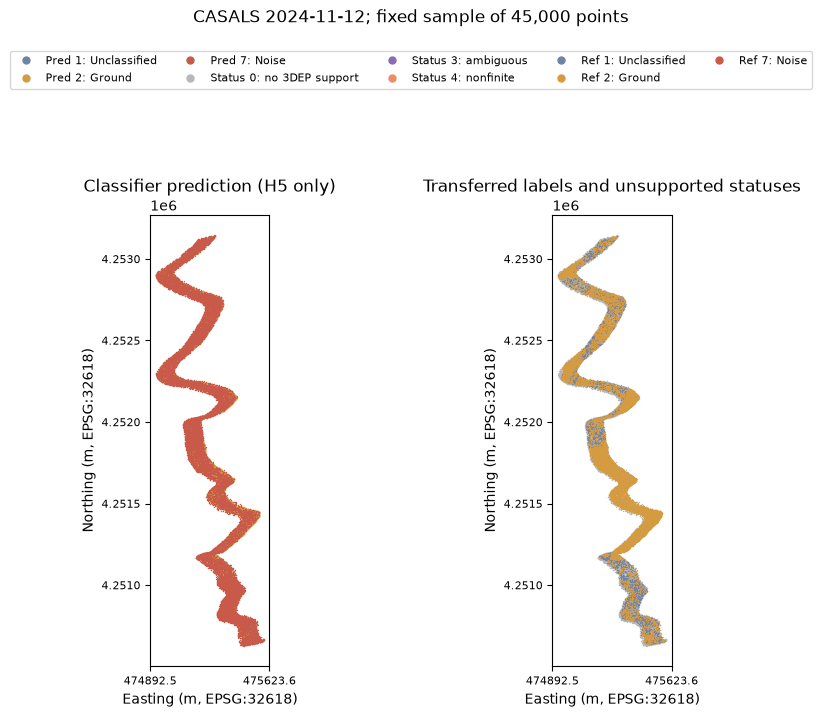

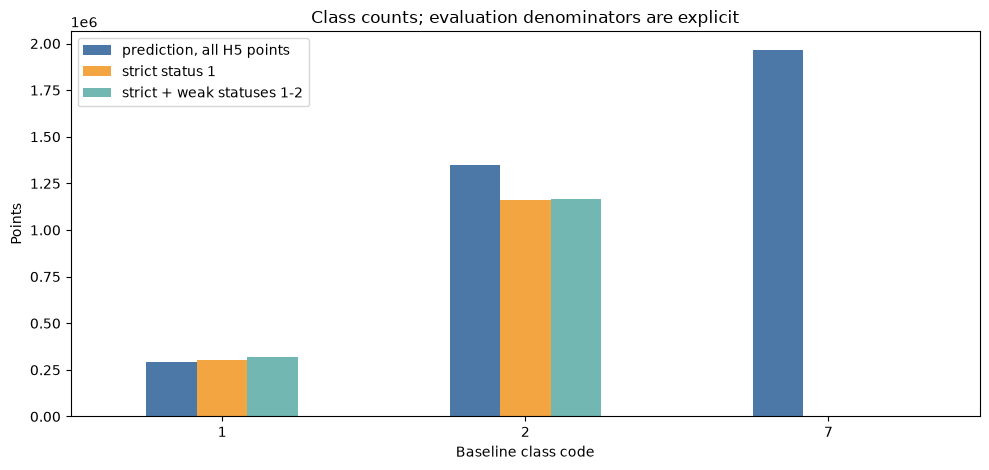

In [4]:
from matplotlib.lines import Line2D
projected = project_refh_points(points)
rng = np.random.default_rng(SEED)
idx = rng.choice(prediction_class.size, size=min(PLOT_SAMPLE, prediction_class.size), replace=False)
colors = {1: "#6f83a6", 2: "#d49b41", 7: "#c95a49"}
map_names = {1: "Unclassified", 2: "Ground", 7: "Noise"}
fig, axes = plt.subplots(1, 2, figsize=(14, 7.2), constrained_layout=False)
for cls in LABEL_ORDER:
    selected = idx[prediction_class[idx] == cls]
    if selected.size:
        axes[0].scatter(projected.easting[selected], projected.northing[selected],
                        s=1, c=colors[cls], label=f"{cls}: {map_names[cls]}",
                        linewidths=0, rasterized=True)
axes[0].set_title("Classifier prediction (H5 only)")
status_sample = status[idx]
status_colors = {0: "#b8b8b8", 3: "#8c6bb1", 4: "#ef8a62"}
status_map_names = {0: "No 3DEP support", 3: "Ambiguous transfer", 4: "Nonfinite"}
for code, color in status_colors.items():
    selected = idx[status_sample == code]
    if selected.size:
        axes[1].scatter(projected.easting[selected], projected.northing[selected], s=1,
                        c=color, label=f"status {code}: {status_map_names[code]}", linewidths=0, rasterized=True)
for cls in LABEL_ORDER:
    selected = idx[np.isin(status_sample, [1, 2]) & (reference_class[idx] == cls)]
    if selected.size:
        axes[1].scatter(projected.easting[selected], projected.northing[selected], s=1,
                        c=colors[cls], label=f"{cls}: {map_names[cls]} pseudo-label", linewidths=0, rasterized=True)
axes[1].set_title("Transferred labels and unsupported statuses")
for ax in axes:
    ax.set_xlabel("Easting (m, EPSG:32618)")
    ax.set_ylabel("Northing (m, EPSG:32618)")
    ax.set_aspect("equal", adjustable="box")
    ax.xaxis.set_major_locator(plt.LinearLocator(2))
    ax.tick_params(labelsize=8)
legend_specs = [
    (colors[1], "Pred 1: Unclassified"), (colors[2], "Pred 2: Ground"), (colors[7], "Pred 7: Noise"),
    (status_colors[0], "Status 0: no 3DEP support"), (status_colors[3], "Status 3: ambiguous"),
    (status_colors[4], "Status 4: nonfinite"),
    (colors[1], "Ref 1: Unclassified"), (colors[2], "Ref 2: Ground"), (colors[7], "Ref 7: Noise"),
]
legend_handles = [Line2D([], [], marker="o", linestyle="", color=color, markersize=5)
                  for color, _ in legend_specs]
fig.legend(legend_handles, [label for _, label in legend_specs], loc="upper center",
           bbox_to_anchor=(0.5, 0.94), ncol=5, fontsize=8, frameon=True)
fig.tight_layout(rect=(0, 0, 1, 0.82))
fig.suptitle(f"CASALS 2024-11-12; fixed sample of {idx.size:,} points", y=0.99)
fig.tight_layout(rect=(0, 0, 1, 0.82))
plt.show()

pred_counts = pd.Series(prediction_class).value_counts().reindex(LABEL_ORDER, fill_value=0)
strict_ref = pd.Series(reference_class[eval_mask & (status == 1)]).value_counts().reindex(LABEL_ORDER, fill_value=0)
weak_ref = pd.Series(reference_class[eval_mask & np.isin(status, [1, 2])]).value_counts().reindex(LABEL_ORDER, fill_value=0)
comparison = pd.DataFrame({"prediction, all H5 points": pred_counts,
                           "strict status 1": strict_ref,
                           "strict + weak statuses 1-2": weak_ref})
ax = comparison.plot(kind="bar", figsize=(10, 4.8), color=["#4c78a8", "#f2a541", "#72b7b2"])
ax.set(title="Class counts; evaluation denominators are explicit", xlabel="Baseline class code",
       ylabel="Points", xticklabels=[str(v) for v in LABEL_ORDER])
ax.legend()
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## Strict and strict-plus-weak evaluation

The primary matrix uses transfer status 1 only. The sensitivity matrix adds status 2. Statuses 0, 3, and 4 are excluded from both; all scores measure agreement with spatially transferred 3DEP pseudo-labels, not independent accuracy.

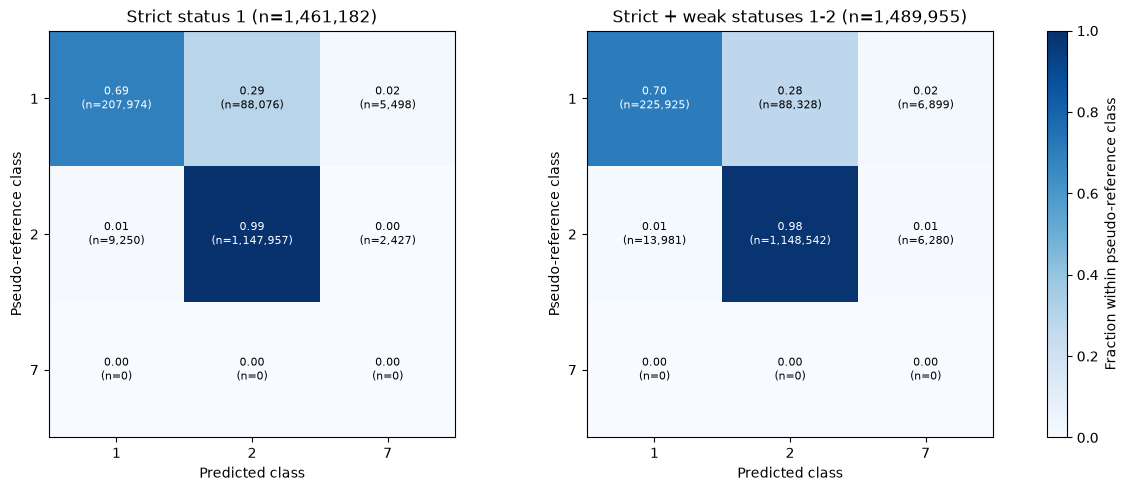

Strict status 1 {'n': 1461182, 'accuracy': 0.9279685898129049, 'macro_f1_fixed_classes': 0.5867181801660487, 'weighted_f1': 0.9260498023223072, 'confusion_matrix': [[207974, 88076, 5498], [9250, 1147957, 2427], [0, 0, 0]]}
Strict + weak statuses 1-2 {'n': 1489955, 'accuracy': 0.9224889342295572, 'macro_f1_fixed_classes': 0.5867382457337004, 'weighted_f1': 0.9226356514930225, 'confusion_matrix': [[225925, 88328, 6899], [13981, 1148542, 6280], [0, 0, 0]]}


In [5]:
def show_evaluation(ax, item, title):
    matrix = np.asarray(item["confusion_matrix"], dtype=np.int64)
    row_total = matrix.sum(axis=1, keepdims=True)
    rate = np.divide(matrix, row_total, out=np.zeros_like(matrix, dtype=float), where=row_total > 0)
    image = ax.imshow(rate, cmap="Blues", vmin=0, vmax=1)
    ax.set_xticks(range(3), [str(v) for v in LABEL_ORDER])
    ax.set_yticks(range(3), [str(v) for v in LABEL_ORDER])
    ax.set(xlabel="Predicted class", ylabel="Pseudo-reference class", title=f"{title} (n={item['n_points']:,})")
    for row in range(3):
        for col in range(3):
            ax.text(col, row, f"{rate[row, col]:.2f}\n(n={matrix[row, col]:,})",
                    ha="center", va="center", color="white" if rate[row, col] > .55 else "black", fontsize=8)
    return image

fig, axes = plt.subplots(1, 2, figsize=(12, 4.8), constrained_layout=True)
image = show_evaluation(axes[0], strict, "Strict status 1")
show_evaluation(axes[1], strict_weak, "Strict + weak statuses 1-2")
fig.colorbar(image, ax=axes, label="Fraction within pseudo-reference class")
plt.show()
for label, item in [("Strict status 1", strict), ("Strict + weak statuses 1-2", strict_weak)]:
    print(label, {"n": item["n_points"], "accuracy": item["accuracy"],
                  "macro_f1_fixed_classes": item["macro_f1"], "weighted_f1": item["weighted_f1"],
                  "confusion_matrix": item["confusion_matrix"]})

## Representative supported-label errors

Error examples are grouped by pseudo-reference/prediction class pair, then sampled at evenly spaced `point_index` values within each group. They include classifier reason, HAG, SNR, projected location, transfer distance, and vote ratio. This is a review sample, not a correction list.

In [6]:
from casals_l1b.classification import CLASS_REASON_MAP
supported_mask = eval_mask & np.isin(status, [1, 2])
error_idx = np.flatnonzero(supported_mask & (prediction_class != reference_class))
reason = np.asarray(classification_arrays["classification_reason"], dtype=np.uint8)
hag = np.asarray(classification_arrays["height_above_ground_m"], dtype=np.float64)
snr = np.asarray(classification_arrays["refh_snr"], dtype=np.float64)
nearest = alignment["reference_nearest3dep_dist_m"]
vote = alignment["reference_class_vote_ratio"]
if error_idx.size:
    error_frame = pd.DataFrame({
        "point_index": error_idx,
        "transfer_status": [status_names[int(v)] for v in status[error_idx]],
        "pseudo_reference": reference_class[error_idx],
        "prediction": prediction_class[error_idx],
        "prediction_reason": [CLASS_REASON_MAP.get(int(v), "unknown") for v in reason[error_idx]],
        "refh_snr": snr[error_idx], "height_above_ground_m": hag[error_idx],
        "easting_m": projected.easting[error_idx], "northing_m": projected.northing[error_idx],
        "nearest_3dep_distance_m": nearest[error_idx], "class_vote_ratio": vote[error_idx],
    })
    selected_groups = []
    for _, group in error_frame.sort_values("point_index").groupby(["pseudo_reference", "prediction"], sort=True):
        positions = np.linspace(0, len(group) - 1, min(3, len(group)), dtype=int)
        selected_groups.append(group.iloc[np.unique(positions)])
    display(pd.concat(selected_groups, ignore_index=True))
else:
    print("No errors in the explicit supported-label evaluation population.")
print(f"Supported-label errors (statuses 1-2): {error_idx.size:,} / {int(supported_mask.sum()):,} evaluated points")

,point_index,transfer_status,pseudo_reference,prediction,prediction_reason,refh_snr,height_above_ground_m,easting_m,northing_m,nearest_3dep_distance_m,class_vote_ratio
0,9,strict_3dep_label,1,2,ground_abs_hag_within_tol,2.305498,-0.737283,475510.594822,4.250646e+06,1.066272,1.000000
1,2747591,strict_3dep_label,1,2,ground_abs_hag_within_tol,2.502756,0.235936,475124.581514,4.252476e+06,0.130599,0.666667
2,3604478,strict_3dep_label,1,2,ground_abs_hag_within_tol,2.988240,0.211333,475289.045790,4.253142e+06,0.252336,0.750000
3,134,strict_3dep_label,1,7,noise_below_ground,2.022117,-2.769988,475502.121472,4.250644e+06,1.788353,1.000000
4,722278,strict_3dep_label,1,7,noise_below_ground,1.986283,-15.675964,475285.931954,4.251108e+06,0.650765,1.000000
5,3604423,weak_3dep_label,1,7,noise_low_density_processed_only,1.357942,10.237005,475210.116665,4.253124e+06,2.187332,1.000000
6,1209,weak_3dep_label,2,1,processed_unclassified_valid_hag,1.794872,2.740413,475568.062130,4.250657e+06,2.841812,0.666667
7,2769628,strict_3dep_label,2,1,processed_unclassified_valid_hag,1.689167,1.909256,475209.903211,4.252511e+06,1.874123,0.916667
8,3604465,strict_3dep_label,2,1,processed_unclassified_valid_hag,1.805800,2.218963,475243.877297,4.253132e+06,1.980952,0.916667
9,518,strict_3dep_label,2,7,noise_below_ground,1.992540,-16.615261,475501.441967,4.250645e+06,1.109282,0.750000


Supported-label errors (statuses 1-2): 115,488 / 1,489,955 evaluated points


## Interpretation and limitations

- The classifier receives CASALS H5 only; evaluation starts after the prediction artifact is written.
- Alignment verifies the H5 path, unique complete `point_index`, longitude, latitude, and original Refh height against the transferred reference metadata.
- Primary evaluation uses transfer status 1; the sensitivity population adds status 2. Statuses 0, 3, and 4 are excluded from both.
- The transferred 3DEP labels are a spatial pseudo-reference. Its Z values include one empirical shift and do not represent a rigorous vertical-datum transformation.
- Metrics describe agreement with those transferred labels. They do not certify independent classification accuracy.